# Data visualization with Python, Matplotlib, and Seaborn

This notebook uses the **Wine Recognition** dataset included with scikit-learn. It contains 178 wine samples from three cultivars and 13 chemical measurements for each sample.

We will move from a quick data check to comparisons, distributions, relationships, and a correlation heatmap. The goal is not only to make attractive charts, but to choose a chart that answers a clear question.

## Learning goals

- Load a real dataset into a pandas DataFrame.
- Build and customize categorical, distribution, relationship, and matrix charts.
- Know when to use Matplotlib directly and when Seaborn is a better fit.
- Read a visualization carefully and write evidence-based observations.

**Dataset note:** the original data comes from the UCI Machine Learning Repository and is bundled with scikit-learn, so this notebook does not need an internet connection. The target values identify three cultivars; they are not individual wine brand names.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["figure.dpi"] = 110

print(f"pandas {pd.__version__} | seaborn {sns.__version__}")

pandas 3.0.6 | seaborn 0.13.2


## 1. Load and inspect the data

A good visualization workflow starts with basic checks: dimensions, data types, missing values, and a few rows. These checks prevent us from drawing conclusions from an incorrectly loaded or transformed dataset.

In [2]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()
df = df.rename(columns={"target": "cultivar_code"})
df["cultivar"] = df["cultivar_code"].map({
    0: "Cultivar 1",
    1: "Cultivar 2",
    2: "Cultivar 3",
})

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
print(f"Missing cells: {df.isna().sum().sum()}")
display(df.head())

Rows: 178 | Columns: 15
Missing cells: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar_code,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar 1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar 1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar 1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar 1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar 1


In [3]:
feature_labels = {
    "alcohol": "Alcohol",
    "malic_acid": "Malic acid",
    "ash": "Ash",
    "alcalinity_of_ash": "Alcalinity of ash",
    "magnesium": "Magnesium",
    "total_phenols": "Total phenols",
    "flavanoids": "Flavanoids",
    "nonflavanoid_phenols": "Nonflavanoid phenols",
    "proanthocyanins": "Proanthocyanins",
    "color_intensity": "Color intensity",
    "hue": "Hue",
    "od280/od315_of_diluted_wines": "OD280/OD315",
    "proline": "Proline",
}
feature_cols = list(feature_labels)
display(df[feature_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


## 2. How many samples belong to each cultivar?

A bar chart is a natural choice for comparing counts across a small set of categories. Here we use **Matplotlib** directly so the key pieces—figure, axes, bars, labels, and annotations—are visible.

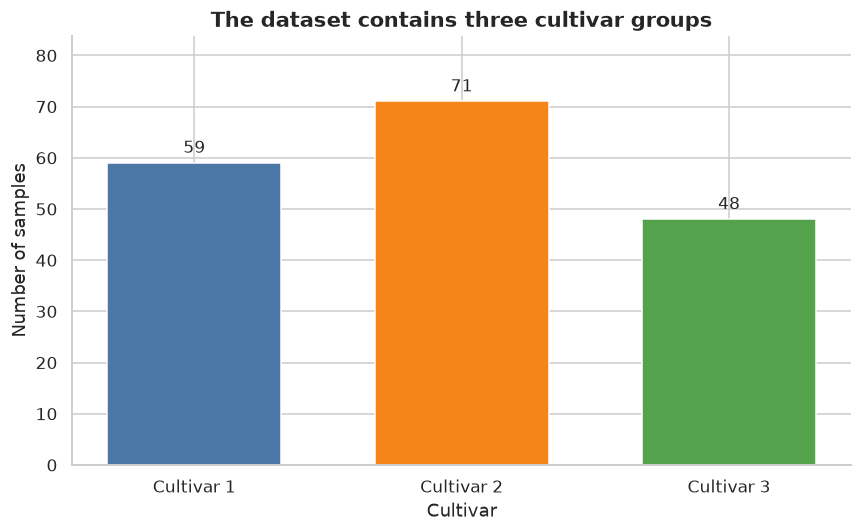

cultivar
Cultivar 1    59
Cultivar 2    71
Cultivar 3    48
Name: count, dtype: int64

In [4]:
class_counts = df["cultivar"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=["#4C78A8", "#F58518", "#54A24B"],
    width=0.65,
)
ax.set_title("The dataset contains three cultivar groups")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, max(class_counts.values) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.bar_label(bars, padding=4, fontsize=11)
plt.tight_layout()
plt.show()

class_counts

The groups are not perfectly balanced, so proportions are worth keeping in mind when comparing them. A difference in group size should not automatically be interpreted as a difference in typical chemistry.

## 3. How does alcohol vary by cultivar?

A distribution plot shows more than a group average. A **boxplot** summarizes the median, middle 50% of observations, and potential outliers, while the overlaid points show the individual samples. Seaborn handles the grouping and statistical styling concisely.

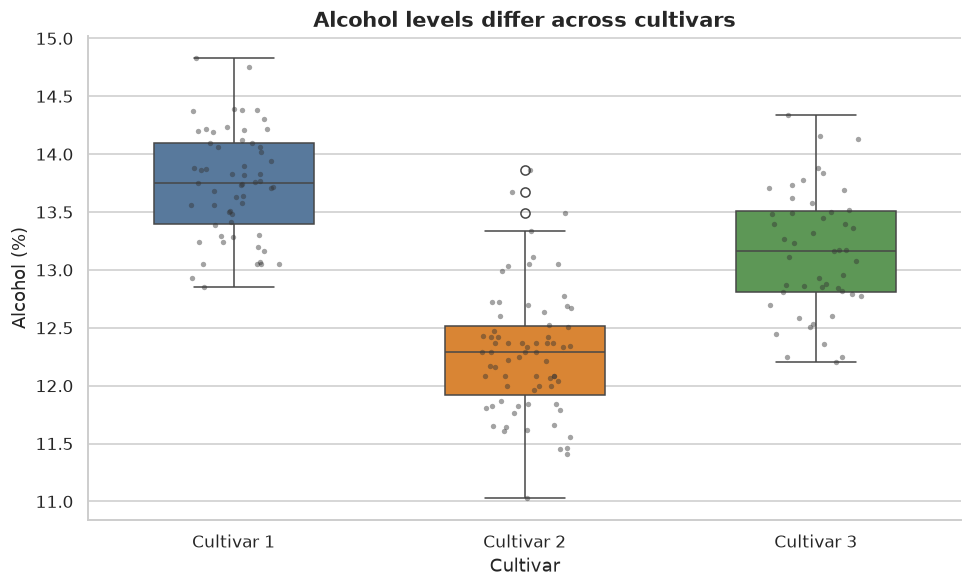

,count,mean,median,min,max
cultivar,,,,,
Cultivar 1,59,13.74,13.75,12.85,14.83
Cultivar 2,71,12.28,12.29,11.03,13.86
Cultivar 3,48,13.15,13.16,12.20,14.34


In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(
    data=df,
    x="cultivar",
    y="alcohol",
    hue="cultivar",
    palette=["#4C78A8", "#F58518", "#54A24B"],
    legend=False,
    width=0.55,
    ax=ax,
)
sns.stripplot(
    data=df,
    x="cultivar",
    y="alcohol",
    color="#333333",
    alpha=0.45,
    jitter=0.16,
    size=3.5,
    ax=ax,
)
ax.set_title("Alcohol levels differ across cultivars")
ax.set_xlabel("Cultivar")
ax.set_ylabel("Alcohol (%)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

df.groupby("cultivar")["alcohol"].agg(["count", "mean", "median", "min", "max"]).round(2)

### Reading the chart

- Compare the median lines to see which group has the highest typical alcohol level.
- Compare the box heights to see which group has more variation in its middle 50%.
- Look at the points outside the boxes as observations worth checking, not automatic errors.

The table below the chart is useful because it gives exact values that the plot intentionally summarizes.

## 4. Is there a relationship between flavanoids and proline?

A scatter plot is appropriate when both variables are numeric and we want to inspect a relationship. Coloring the points by cultivar lets us see whether the groups overlap or form distinct regions.

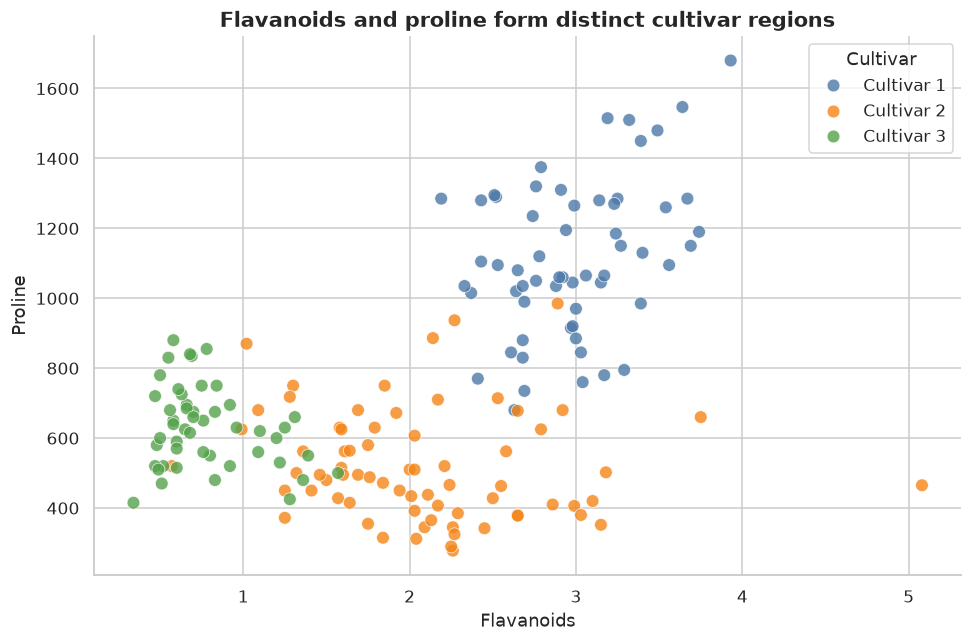

,flavanoids,proline
flavanoids,1.00,0.49
proline,0.49,1.00


In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="flavanoids",
    y="proline",
    hue="cultivar",
    palette={
        "Cultivar 1": "#4C78A8",
        "Cultivar 2": "#F58518",
        "Cultivar 3": "#54A24B",
    },
    s=70,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)
ax.set_title("Flavanoids and proline form distinct cultivar regions")
ax.set_xlabel("Flavanoids")
ax.set_ylabel("Proline")
ax.legend(title="Cultivar", frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

df[["flavanoids", "proline"]].corr().round(2)

A visible pattern does not by itself prove causation. It tells us that the two measurements move together in this sample and may be useful for distinguishing cultivar groups.

## 5. Which measurements move together?

A correlation heatmap compresses many pairwise comparisons into one matrix. We use a carefully chosen subset so the labels remain readable. The diagonal is always 1 because each variable is perfectly correlated with itself.

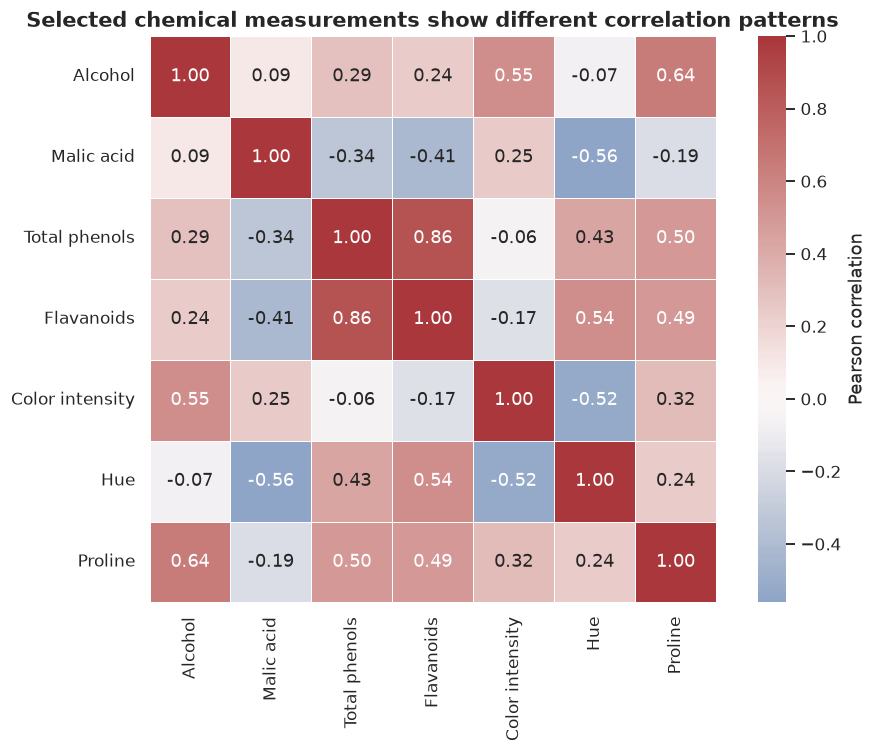

In [7]:
heatmap_features = [
    "alcohol",
    "malic_acid",
    "total_phenols",
    "flavanoids",
    "color_intensity",
    "hue",
    "proline",
]
corr = df[heatmap_features].corr()
pretty_labels = [feature_labels[col] for col in heatmap_features]
corr.index = pretty_labels
corr.columns = pretty_labels

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Selected chemical measurements show different correlation patterns")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Correlation is a screening tool

Strong correlation can help us identify redundant features or promising variables for a model. It does not tell us that one measurement causes another, and it can be influenced by the three cultivar groups being mixed together.

## 6. Compare many distributions at once

A violin plot combines a boxplot-like summary with a smoothed view of the distribution. Here we standardize a small set of features first so variables with very different units can share one axis. The standardized value is measured in standard deviations from that feature's overall mean.

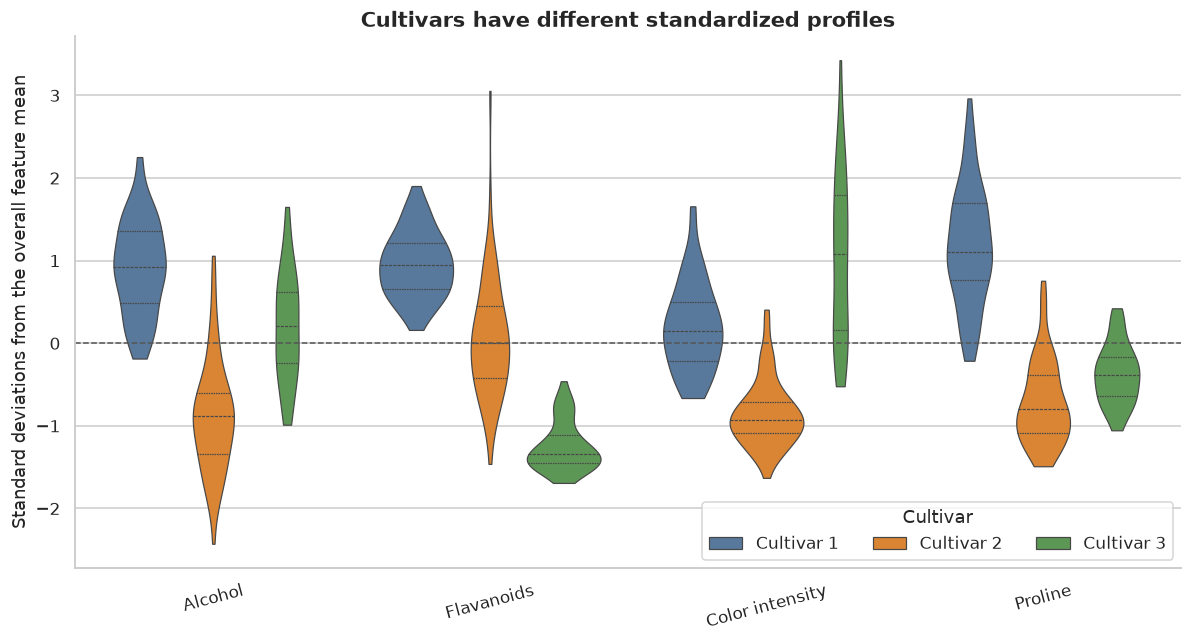

In [8]:
violin_features = ["alcohol", "flavanoids", "color_intensity", "proline"]
long_df = df[["cultivar"] + violin_features].melt(
    id_vars="cultivar",
    var_name="feature",
    value_name="raw_value",
)
long_df["standardized_value"] = long_df.groupby("feature")["raw_value"].transform(
    lambda values: (values - values.mean()) / values.std()
)
long_df["feature"] = long_df["feature"].map(feature_labels)

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(
    data=long_df,
    x="feature",
    y="standardized_value",
    hue="cultivar",
    palette={
        "Cultivar 1": "#4C78A8",
        "Cultivar 2": "#F58518",
        "Cultivar 3": "#54A24B",
    },
    inner="quartile",
    cut=0,
    linewidth=0.8,
    ax=ax,
)
ax.axhline(0, color="#555555", linewidth=1, linestyle="--")
ax.set_title("Cultivars have different standardized profiles")
ax.set_xlabel("")
ax.set_ylabel("Standard deviations from the overall feature mean")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Cultivar", ncol=3, frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Findings from this exploration

The charts suggest that cultivar groups differ across several chemical measurements, rather than along just one variable. Alcohol, flavanoids, proline, and color intensity are useful places to look first because their distributions and group separation are visually distinct in this sample. The heatmap also shows that some measurements move together, so a model using every feature may contain redundant information.

These are descriptive findings about this dataset—not claims about all wines. A next analysis could use a train/test split and a classifier, then evaluate whether the visual separation translates into predictive performance.

## Practice exercises

1. Replace `alcohol` in the boxplot with `magnesium`. What changes in the group comparison?
2. Add a `style="cultivar"` argument to the scatter plot and compare the result with using color alone.
3. Create a horizontal bar chart of the mean value of each feature for `Cultivar 1`.
4. Use `sns.pairplot` on `alcohol`, `flavanoids`, `color_intensity`, and `proline`, colored by cultivar. Which pair looks most useful for separating the groups?
5. Write one sentence that describes a pattern and one sentence that explicitly avoids claiming causation.